# Octree / Interpolator Demo

This notebook demonstrates the current prototype work in:

- `octree/interpolator.py`

Scope:

1. Read a data file as a plain `Dataset` (no `SmartDs`)
2. Compute per-cell `delta_phi` and inferred refinement levels
3. Build an octree summary
4. Run cell lookup in both `xyz` and `(r,polar,azimuth)`
5. Use the interpolator
6. Run ray walk and ray sampling
7. Build piecewise linear ray functions via tet split and integrate them exactly


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import LinearNDInterpolator
from starwinds_readplt.dataset import Dataset
from pathlib import Path

def data_file(name: str) -> Path:
    return Path('/Users/dagfev/Documents/starwinds/octree/example_data') / name
from octree import Octree
from octree import OctreeBuilder
from octree import OctreeInterpolator
from octree import OctreeRayInterpolator
from octree import OctreeRayTracer
from octree import format_histogram
from octree import format_octree_summary
np.set_printoptions(precision=6, suppress=True)


### Pick the mixed-level 3D file used during development.

In [2]:
path = data_file('difflevels-3d__var_1_n00000000.dat')
path


PosixPath('/Users/dagfev/Documents/starwinds/octree/example_data/difflevels-3d__var_1_n00000000.dat')

### Plain Dataset read (no SmartDs)

In [3]:
ds = Dataset.from_file(str(path))
print(ds)


Title:     'BATSRUS: 3D Data, 2011/02/16 17:26:00.000'
Zone:      '3D   N=0000000'
Variables: 24
Shape:     (432512, 24)
Variables: ['X [R]', 'Y [R]', 'Z [R]', 'Rho [g/cm^3]', 'U_x [km/s]', 'U_y [km/s]', 'U_z [km/s]', 'ti [K]', 'te [K]', 'B_x [Gauss]', 'B_y [Gauss]', 'B_z [Gauss]', 'I01 [erg/cm^3]', 'I02 [erg/cm^3]', 'P [dyne/cm^2]', 'pe [dyne/cm^2]', 'E [erg/cm^3]', 'ehot [erg/cm^3]', 'qrad J/m^3/s', 'qheat J/m^3/s', 'refl 1/s', 'J_x [`uA/m^2]', 'J_y [`uA/m^2]', 'J_z [`uA/m^2]'].


### Build octree and inspect inferred levels

In [4]:
tree = Octree.from_dataset(ds, coord_system='rpa')
builder = OctreeBuilder()
delta_phi, center_phi, cell_levels, expected_delta_phi, coarse_delta_phi = builder.compute_phi_levels(ds)
print('coarsest delta_phi [rad]:', coarse_delta_phi)
print('cell level histogram:', format_histogram(cell_levels))


coarsest delta_phi [rad]: 0.19634991947356895
cell level histogram: 0:3072, 1:24576, 2:393216


### Octree summary

In [5]:
print(format_octree_summary(tree))


Octree (adaptive): coord_system=rpa, finest_leaf_grid=(96, 64, 128), root_grid=(3, 2, 4), depth=5, full=True, levels=0..2; leaf_levels[L0:3072 (fine-equiv 196608), L1:24576 (fine-equiv 196608), L2:393216 (fine-equiv 393216)]


### Lookup in xyz and rpa

In [6]:
lookup = tree.lookup
q_xyz = (1.0, 0.0, 0.0)
hit_xyz = lookup.lookup_point(np.array(q_xyz, dtype=float), space="xyz")
print('lookup xyz:', q_xyz, '->', hit_xyz)
r, polar, azimuth = tree.xyz_to_rpa(np.asarray(q_xyz, dtype=float))
hit_rpa = lookup.lookup_point(np.array([r, polar, azimuth], dtype=float), space="rpa")
print('lookup rpa:', (r, polar, azimuth), '->', hit_rpa)
print('same cell id?', hit_xyz is not None and hit_rpa is not None and hit_xyz.cell_id == hit_rpa.cell_id)


lookup xyz: (1.0, 0.0, 0.0) -> LookupHit(cell_id=22728, level=2, i0=0, i1=32, i2=0, path=((0, 1, 0), (0, 2, 0), (0, 4, 0), (0, 8, 0), (0, 16, 0), (0, 32, 0)), center_xyz=(0.99938005, 0.024533403750000002, -0.02454819))
lookup rpa: (1.0, 1.5707963267948966, 0.0) -> LookupHit(cell_id=22728, level=2, i0=0, i1=32, i2=0, path=((0, 1, 0), (0, 2, 0), (0, 4, 0), (0, 8, 0), (0, 16, 0), (0, 32, 0)), center_xyz=(0.99938005, 0.024533403750000002, -0.02454819))
same cell id? True


### Interpolator usage

In [7]:
interp = OctreeInterpolator(
    ds,
    ['Rho [g/cm^3]'],
    query_space='xyz',
    tree=tree,
)
queries = np.array([
    [1.0, 0.0, 0.0],
    [5.0, 0.0, 0.0],
    [10.0, 1.0, 0.5],
], dtype=float)
vals, cell_ids = interp(queries, return_cell_ids=True)
print('queries:')
print(queries)
print('values:')
print(vals)
print('cell ids:')
print(cell_ids)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


queries:
[[ 1.   0.   0. ]
 [ 5.   0.   0. ]
 [10.   1.   0.5]]
values:
[0. 0. 0.]
cell ids:
[ 22728  47688 149128]


### Optional: lightweight comparison to SciPy LinearNDInterpolator.

To keep notebook runtime reasonable, this uses a point subset.

In [8]:
xyz = np.column_stack([
    np.asarray(ds.variable('X [R]'), dtype=float),
    np.asarray(ds.variable('Y [R]'), dtype=float),
    np.asarray(ds.variable('Z [R]'), dtype=float),
])
vv = np.asarray(ds.variable('Rho [g/cm^3]'), dtype=float)
rng = np.random.default_rng(0)
n_sub = min(40000, xyz.shape[0])
sub = rng.choice(xyz.shape[0], size=n_sub, replace=False)
lin = LinearNDInterpolator(xyz[sub], vv[sub], fill_value=np.nan)
q = xyz[rng.choice(xyz.shape[0], size=2000, replace=False)]
ours = interp(q)
scipy_vals = lin(q)
mask = np.isfinite(ours) & np.isfinite(scipy_vals)
print('scipy subset size:', n_sub)
print('finite overlap fraction:', float(np.mean(mask)))
if np.any(mask):
    ad = np.abs(ours[mask] - scipy_vals[mask])
    print('max abs diff:', float(np.max(ad)))
    print('median abs diff:', float(np.median(ad)))


scipy subset size: 40000
finite overlap fraction: 0.999
max abs diff: 2.1924066683202364e-13
median abs diff: 2.3873812657280164e-19


### Ray walk and sampled values along the ray

In [9]:
r_shell = 4.0
p_start = r_shell * np.array([1.0, 0.0, 0.0], dtype=float)
p_end = r_shell * np.array([-0.25, 0.96, 0.11], dtype=float)
p_end = r_shell * (p_end / np.linalg.norm(p_end))
origin = p_start
direction = p_end - p_start
t0, t1 = 0.0, float(np.linalg.norm(direction))
segments = OctreeRayTracer(interp.tree).trace(origin, direction, t0, t1)
print('ray start:', p_start, 'r=', float(np.linalg.norm(p_start)))
print('ray end:', p_end, 'r=', float(np.linalg.norm(p_end)))
print('segment count:', len(segments))
if segments:
    print('first segment:', segments[0])
    print('last segment:', segments[-1])
n_samples = 1200
t_values, ray_values, ray_cell_ids, _ = OctreeRayInterpolator(interp).sample(origin, direction, t0, t1, n_samples)
print('sample count:', n_samples)
print('nan fraction:', float(np.mean(~np.isfinite(ray_values))))


ray start: [4. 0. 0.] r= 4.0
ray end: [-1.001905  3.847317  0.440838] r= 4.0
segment count: 53
first segment: RaySegment(cell_id=29739, t_enter=0.0, t_exit=5.725317463327142e-07)
last segment: RaySegment(cell_id=165081, t_enter=6.265916785596681, t_exit=6.325760306685489)
sample count: 1200
nan fraction: 0.0


### Piecewise linear functions over the ray via tet split

In [10]:
pieces = OctreeRayInterpolator(interp).linear_pieces(origin, direction, t0, t1)
print('linear piece count:', len(pieces))
if pieces:
    print('coverage:', pieces[0].t_start, '->', pieces[-1].t_end)
    for i, p in enumerate(pieces[:6]):
        print(i, (p.t_start, p.t_end), 'cell', p.cell_id, 'tet', p.tet_id, 'slope', float(np.asarray(p.slope)), 'intercept', float(np.asarray(p.intercept)))


linear piece count: 158
coverage: 0.0 -> 6.325760306685489
0 (0.0, 5.725317463327142e-07) cell 29739 tet 4 slope 4.226493608141687e-19 intercept 6.706485020017684e-19
1 (5.725317463327142e-07, 0.1507364424295736) cell 112227 tet 0 slope 4.2078944766778143e-19 intercept 6.706485020017684e-19
2 (0.1507364424295736, 0.30370033305509997) cell 112227 tet 0 slope 4.2078944766778143e-19 intercept 6.706485020017684e-19
3 (0.30370033305509997, 0.3106380610290288) cell 112233 tet 4 slope 4.0354007207879728e-19 intercept 6.758872175137015e-19
4 (0.3106380610290288, 0.31826642886334366) cell 112233 tet 3 slope 4.0354197603048736e-19 intercept 6.758866260738398e-19
5 (0.31826642886334366, 0.340358221041932) cell 112232 tet 0 slope 5.486367508086178e-19 intercept 6.295714810680252e-19


### Evaluate the piecewise linear model on the sample t-grid and compare with direct interpolation.

In [11]:
piece_vals = np.full_like(ray_values, np.nan)
idx = 0
for i, t in enumerate(t_values):
    while idx + 1 < len(pieces) and t > pieces[idx].t_end:
        idx += 1
    if idx < len(pieces):
        p = pieces[idx]
        if p.t_start - 1e-8 <= t <= p.t_end + 1e-8:
            piece_vals[i] = p.slope * t + p.intercept
mask = np.isfinite(piece_vals) & np.isfinite(ray_values)
print('piece finite fraction:', float(np.mean(np.isfinite(piece_vals))))
if np.any(mask):
    diff = np.abs(piece_vals[mask] - ray_values[mask])
    print('max abs diff:', float(np.max(diff)))
    print('median abs diff:', float(np.median(diff)))


piece finite fraction: 1.0
max abs diff: 3.358396754902471e-19
median abs diff: 2.3193547256301818e-21


### Exact integration of piecewise linear model:

integral_{a}^{b} (m*t + b0) dt = 0.5*m*(b^2-a^2) + b0*(b-a)

In [12]:
integral_exact = np.asarray(0.0, dtype=float)
for p in pieces:
    a = float(p.t_start)
    b = float(p.t_end)
    integral_exact = integral_exact + 0.5 * p.slope * (b * b - a * a) + p.intercept * (b - a)
# Numerical check against dense trapezoid on ray samples
integral_trap = np.trapezoid(ray_values, t_values)
print('exact piecewise-linear integral:', float(np.asarray(integral_exact)))
print('trapz(ray samples):', float(np.asarray(integral_trap)))
print('abs difference:', float(np.abs(np.asarray(integral_exact) - np.asarray(integral_trap))))


exact piecewise-linear integral: 1.1786240232500634e-17
trapz(ray samples): 1.1838531798436403e-17
abs difference: 5.2291565935768965e-20


### 3D ray traversal with per-cell colors and tetrahedral cell rendering.


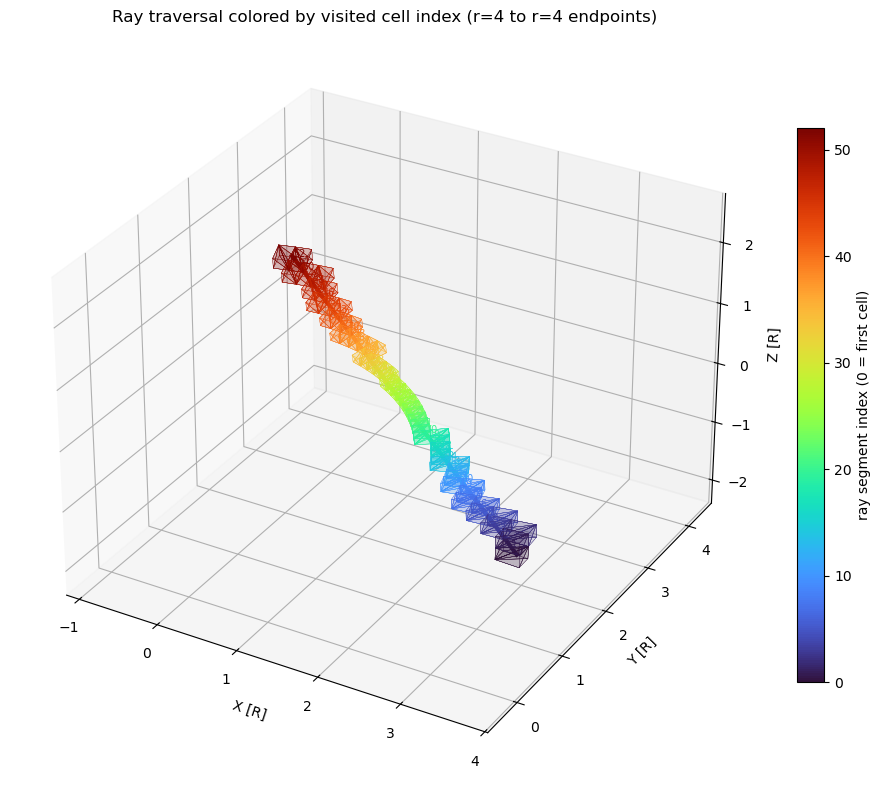

first 12 (segment_index, cell_id):
0 29739
1 112227
2 112233
3 112232
4 112238
5 112237
6 112243
7 112242
8 112416
9 112422
10 112331
11 112337


In [13]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from octree.ray import HEX_TETS_INDEX, TET_FACES_INDEX
if not segments:
    raise RuntimeError('Ray did not traverse any octree cells; adjust ray setup.')
ray_dir = direction / np.linalg.norm(direction)
n_seg = len(segments)
cmap = plt.colormaps['turbo']
colors = cmap(np.linspace(0.0, 1.0, max(n_seg, 2)))
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
all_faces = []
all_facecolors = []
extent_points = []
for idx, seg in enumerate(segments):
    color = colors[idx]
    cid = int(seg.cell_id)
    p0 = origin + float(seg.t_enter) * ray_dir
    p1 = origin + float(seg.t_exit) * ray_dir
    pm = 0.5 * (p0 + p1)
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], color=color, linewidth=3.0)
    ax.text(pm[0], pm[1], pm[2], str(idx), color=color, fontsize=7)
    corner_ids = interp._corners[cid]
    cell_xyz = interp.lookup._points[corner_ids]
    for tet in HEX_TETS_INDEX:
        tet_xyz = cell_xyz[np.asarray(tet, dtype=np.int64)]
        for face in TET_FACES_INDEX:
            all_faces.append(tet_xyz[np.asarray(face, dtype=np.int64)])
            all_facecolors.append(color)
    extent_points.extend([p0, p1])
    extent_points.extend(cell_xyz)
poly = Poly3DCollection(
    all_faces,
    facecolors=all_facecolors,
    edgecolors=all_facecolors,
    linewidths=0.2,
    alpha=0.08,
)
ax.add_collection3d(poly)
extent = np.asarray(extent_points, dtype=float)
mins = np.min(extent, axis=0)
maxs = np.max(extent, axis=0)
center = 0.5 * (mins + maxs)
radius = 0.5 * float(np.max(maxs - mins))
ax.set_xlim(center[0] - radius, center[0] + radius)
ax.set_ylim(center[1] - radius, center[1] + radius)
ax.set_zlim(center[2] - radius, center[2] + radius)
ax.set_xlabel('X [R]')
ax.set_ylabel('Y [R]')
ax.set_zlabel('Z [R]')
ax.set_title('Ray traversal colored by visited cell index (r=4 to r=4 endpoints)')
norm = plt.Normalize(vmin=0, vmax=max(n_seg - 1, 1))
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('ray segment index (0 = first cell)')
plt.tight_layout()
plt.show()
print('first 12 (segment_index, cell_id):')
for i, seg in enumerate(segments[:12]):
    print(i, int(seg.cell_id))


### 3D ray traversal with per-cell colors and hexahedral (cube) cell rendering.


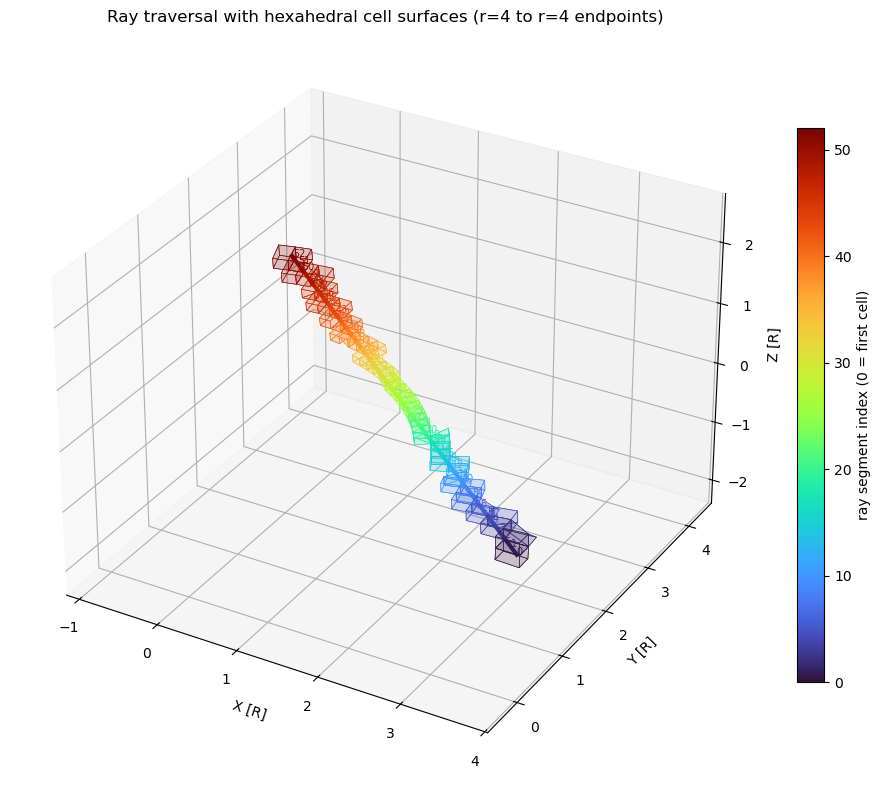

In [14]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
if not segments:
    raise RuntimeError('Ray did not traverse any octree cells; adjust ray setup.')
ray_dir = direction / np.linalg.norm(direction)
n_seg = len(segments)
cmap = plt.colormaps['turbo']
colors = cmap(np.linspace(0.0, 1.0, max(n_seg, 2)))
def cube_index(r_bit, polar_bit, azimuth_bit):
    return int(r_bit + 2 * polar_bit + 4 * azimuth_bit)
cube_faces = [
    [cube_index(0, 0, 0), cube_index(0, 1, 0), cube_index(0, 1, 1), cube_index(0, 0, 1)],
    [cube_index(1, 0, 0), cube_index(1, 0, 1), cube_index(1, 1, 1), cube_index(1, 1, 0)],
    [cube_index(0, 0, 0), cube_index(0, 0, 1), cube_index(1, 0, 1), cube_index(1, 0, 0)],
    [cube_index(0, 1, 0), cube_index(1, 1, 0), cube_index(1, 1, 1), cube_index(0, 1, 1)],
    [cube_index(0, 0, 0), cube_index(1, 0, 0), cube_index(1, 1, 0), cube_index(0, 1, 0)],
    [cube_index(0, 0, 1), cube_index(0, 1, 1), cube_index(1, 1, 1), cube_index(1, 0, 1)],
]
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
all_faces = []
all_facecolors = []
extent_points = []
for idx, seg in enumerate(segments):
    color = colors[idx]
    cid = int(seg.cell_id)
    p0 = origin + float(seg.t_enter) * ray_dir
    p1 = origin + float(seg.t_exit) * ray_dir
    pm = 0.5 * (p0 + p1)
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], color=color, linewidth=3.0)
    ax.text(pm[0], pm[1], pm[2], str(idx), color=color, fontsize=7)
    corner_ids = interp._corners[cid]
    cell_xyz_raw = interp.lookup._points[corner_ids]
    corner_order = interp._bin_to_corner[cid]
    cell_xyz = cell_xyz_raw[corner_order]
    for face in cube_faces:
        all_faces.append(cell_xyz[np.array(face, dtype=np.int64)])
        all_facecolors.append(color)
    extent_points.extend([p0, p1])
    extent_points.extend(cell_xyz)
poly = Poly3DCollection(
    all_faces,
    facecolors=all_facecolors,
    edgecolors=all_facecolors,
    linewidths=0.4,
    alpha=0.12,
)
ax.add_collection3d(poly)
extent = np.array(extent_points, dtype=float)
mins = np.min(extent, axis=0)
maxs = np.max(extent, axis=0)
center = 0.5 * (mins + maxs)
radius = 0.5 * float(np.max(maxs - mins))
ax.set_xlim(center[0] - radius, center[0] + radius)
ax.set_ylim(center[1] - radius, center[1] + radius)
ax.set_zlim(center[2] - radius, center[2] + radius)
ax.set_xlabel('X [R]')
ax.set_ylabel('Y [R]')
ax.set_zlabel('Z [R]')
ax.set_title('Ray traversal with hexahedral cell surfaces (r=4 to r=4 endpoints)')
norm = plt.Normalize(vmin=0, vmax=max(n_seg - 1, 1))
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('ray segment index (0 = first cell)')
plt.tight_layout()
plt.show()
